In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
def f(x0, x1):
    return (1-x0)**2 + 100*(x1-x0**2)**2

##### Data

In [3]:
x = np.arange(-5, 5, 0.01)
y = np.arange(-5, 5, 0.01)

X, Y = np.meshgrid(x, y)

Z = f(X, Y)

##### Affichage 3D

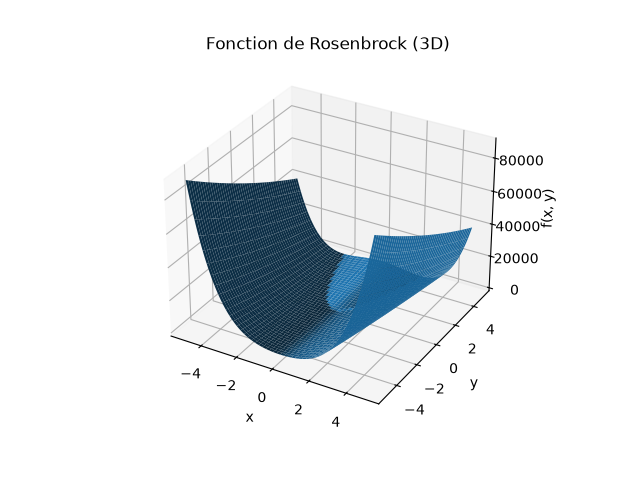

In [4]:
ax = plt.subplot(111, projection='3d')
ax.plot_surface(X, Y, Z)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_title("Fonction de Rosenbrock (3D)")

plt.show()

##### Affichage HeatMap

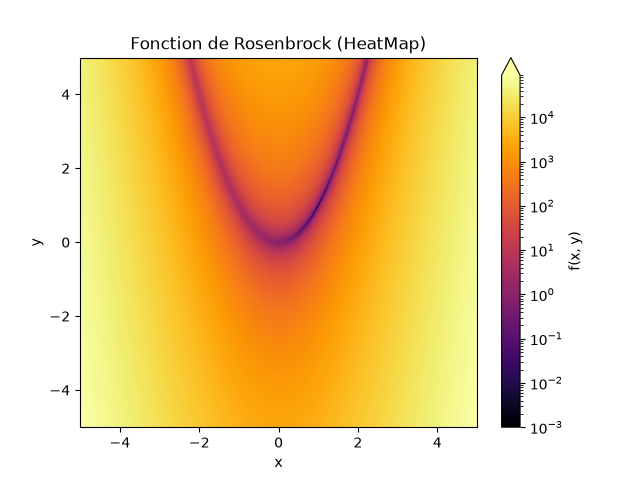

In [5]:
fig, ax = plt.subplots()

norm = LogNorm(vmin=1e-3, vmax=Z.max())
pcm = ax.pcolormesh(X, Y, Z, norm=norm, cmap="inferno", shading="auto")
fig.colorbar(pcm, ax=ax, extend="max", label="f(x, y)")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Fonction de Rosenbrock (HeatMap)")

plt.show()

##### Recherche du minimum

In [6]:
from algo.neldermead import NelderMead
from utils.point import Point

def _f(p: Point)->float:
    x0 = p[0]
    x1 = p[1]

    return f(x0, x1)

initial_simplex_values = [Point([-4, 0]), Point([4, 0]), Point([0, 4])]

algo = NelderMead(initial_simplex_values, _f)
algo.compute(100)

##### Animation

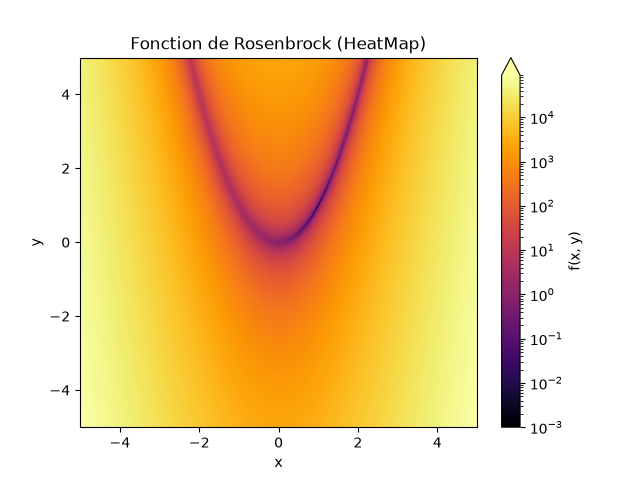

In [7]:
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle
from utils.control import Control
from matplotlib.markers import MarkerStyle

fig, ax = plt.subplots()

pcm = ax.pcolormesh(X, Y, Z, norm=norm, cmap="inferno", shading="auto")
fig.colorbar(pcm, ax=ax, extend="max", label="f(x, y)")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Fonction de Rosenbrock (HeatMap)")

simplex_plot, = ax.plot([], [], "o-", c="cyan", zorder=2)
operation_text = fig.text(0.15, 0.95, "", c="black", verticalalignment="top", zorder=2)

colored_points = ax.scatter([], [], facecolors="none", edgecolors="none", zorder=3, s=35)

def update(frame):
    state = algo.history[frame]
    
    ax.set_title("Step: " + str(state["step"]))

    # Simplex update
    x_simplex = [p[0] for p in state["points"]]
    y_simplex = [p[1] for p in state["points"]]
    x_simplex.append(x_simplex[0])
    y_simplex.append(y_simplex[0])
    simplex_plot.set_data(x_simplex, y_simplex)

    # Operation text update
    operation_text.set_text(state["operation"])

    colored_points_values = []
    colored_points_color = []

    if state["gravity_point"] != None:
        colored_points_values.append([state["gravity_point"][0], state["gravity_point"][1]])
        colored_points_color.append("#1b58ee")
    if state["reflexion_point"] != None:
        colored_points_values.append([state["reflexion_point"][0], state["reflexion_point"][1]])
        colored_points_color.append("#4d6fc4")
    if state["expansion_point"] != None:
        colored_points_values.append([state["expansion_point"][0], state["expansion_point"][1]])
        colored_points_color.append("#3b4638")
    if state["contraction_point"] != None:
        colored_points_values.append([state["contraction_point"][0], state["contraction_point"][1]])
        colored_points_color.append("#79839c")
    if state["best_point"] != None:
        colored_points_values.append([state["best_point"][0], state["best_point"][1]])
        colored_points_color.append("#2ba500")
    if state["worse_point"] != None:
        colored_points_values.append([state["worse_point"][0], state["worse_point"][1]])
        colored_points_color.append("#eb4919")

    print(colored_points_values)
    print(colored_points_color)
    
    if len(colored_points_values) > 0:
        colored_points.set_offsets(colored_points_values)
        colored_points.set_facecolors(colored_points_color)
        colored_points.set_edgecolors(colored_points_color)
    else:
        colored_points.set_offsets(np.empty((0, 2)))

    return simplex_plot, operation_text, colored_points

animation = FuncAnimation(fig, update, frames=len(algo.history), interval=250)
Control(fig, animation, update, len(algo.history))
plt.show()
animation.event_source.stop()